# 02 — Baseline Models, Duration Leakage and Hyperparameter Tuning

This notebook rebuilds the baseline and tuning experiment directly from the source dataset. It separates pre-call modelling from the post-call `duration` diagnostic and performs every search from scratch with `SEED=42`.

No `data/`, `results/` or `figures/` folder is required and no cached parameter/result file is read.

## 1. Validation design and deployable feature sets

A stratified 80/20 development/final-holdout split is fixed with seed 42. Model selection happens only inside development: 24,000 rows for LR tuning, 8,000 for tuning validation, and a reproducible 10,000-row stratified HGB tuning subsample. The final 8,000-row holdout is untouched until selection is complete.

**Coding step.** Load the data, define pre-call and +duration feature sets, and create deterministic development, tuning and final-holdout splits.

**Why this step matters.** Keeping the rationale next to the code makes the analytical sequence, validation logic and interpretation auditable.

In [1]:
from inspect import signature
import json,time,warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,ParameterGrid,ParameterSampler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score
warnings.filterwarnings("ignore")
SEED=42; DATA_SOURCE="term-deposit-marketing-2020-labelled.csv"
NUM_PRE=["age","balance","day","campaign"]; NUM_DURATION=["age","balance","day","duration","campaign"]; CAT=["job","marital","education","default","housing","loan","contact","month"]; PRE=NUM_PRE+CAT; WITH_DURATION=NUM_DURATION+CAT
df=pd.read_csv(DATA_SOURCE)
if "y_binary" in df.columns: df=df.drop(columns="y_binary")
df["y_binary"]=df["y"].eq("yes").astype(int); y=df["y_binary"].to_numpy(); idx=np.arange(len(df))
dev_idx,test_idx=train_test_split(idx,test_size=.20,stratify=y,random_state=SEED); train_idx,val_idx=train_test_split(dev_idx,test_size=.25,stratify=y[dev_idx],random_state=SEED); hgb_tune_idx,_=train_test_split(train_idx,train_size=10000,stratify=y[train_idx],random_state=SEED)
split_summary=pd.DataFrame({"split":["LR tuning train","tuning validation","HGB tuning subsample","development total","final untouched test"],"n":[len(train_idx),len(val_idx),len(hgb_tune_idx),len(dev_idx),len(test_idx)],"base_rate":[y[train_idx].mean(),y[val_idx].mean(),y[hgb_tune_idx].mean(),y[dev_idx].mean(),y[test_idx].mean()]}); display(split_summary.round(4))

,split,n,base_rate
0,LR tuning train,24000,0.0724
1,tuning validation,8000,0.0724
2,HGB tuning subsample,10000,0.0724
3,development total,32000,0.0724
4,final untouched test,8000,0.0724


## 2. Preprocessing and baseline/default hyperparameters

The baseline comparison is deliberately **like-for-like within each model family**. Logistic Regression uses one fixed baseline/default configuration for both the **pre-call** and **+ duration** feature sets; HistGradientBoosting does the same. The baseline experiment therefore changes the information available to the model, **not its model hyperparameters**.

There are only two baseline model specifications: one LR baseline and one HGB baseline. Each is evaluated once with the 12 valid pre-call predictors and once with the same predictors plus post-call `duration`.

**Coding step.** Define preprocessing and metrics, declare the explicit LR/HGB baseline/default settings, and display those identical settings side-by-side for the two feature conditions.

**Why this step matters.** The initial `duration` comparison must be a genuine feature-availability experiment rather than a comparison confounded by different model settings.

In [2]:
def prep(features): return ColumnTransformer([("num",StandardScaler(),[f for f in features if f in NUM_DURATION]),("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),[f for f in features if f in CAT])])
def lr_model(params):
    q=params.copy(); penalty=q.pop("penalty")
    if signature(LogisticRegression).parameters["penalty"].default=="deprecated": q["l1_ratio"]=1.0 if penalty=="l1" else 0.0
    else: q["penalty"]=penalty
    return LogisticRegression(solver="liblinear",max_iter=3000,random_state=SEED,**q)
def hgb_model(params): return HistGradientBoostingClassifier(random_state=SEED,**params)
def pipe(features,model): return Pipeline([("prep",prep(features)),("model",model)])
def baseline(kind):
    if kind=="LR": return LogisticRegression(C=1.0,penalty="l2",solver="lbfgs",max_iter=1000,tol=1e-4,class_weight=None,random_state=SEED)
    return HistGradientBoostingClassifier(loss="log_loss",learning_rate=.1,max_iter=100,max_leaf_nodes=31,max_depth=None,min_samples_leaf=20,l2_regularization=0,max_bins=255,early_stopping="auto",class_weight=None,random_state=SEED)
def metrics(yt,p,t=.5):
    z=(p>=t).astype(int); return {"accuracy":accuracy_score(yt,z),"precision":precision_score(yt,z,zero_division=0),"recall":recall_score(yt,z,zero_division=0),"f1":f1_score(yt,z,zero_division=0),"pr_auc":average_precision_score(yt,p),"roc_auc":roc_auc_score(yt,p)}

# Explicit baseline/default settings; reused unchanged across feature conditions.
BASELINE_PARAMS = {
    "LR": {"C":1.0,"penalty":"l2","solver":"lbfgs","max_iter":1000,"tol":1e-4,"class_weight":None,"random_state":SEED},
    "HGB": {"loss":"log_loss","learning_rate":0.1,"max_iter":100,"max_leaf_nodes":31,"max_depth":None,"min_samples_leaf":20,"l2_regularization":0.0,"max_bins":255,"early_stopping":"auto","class_weight":None,"random_state":SEED},
}

def baseline(kind):
    return LogisticRegression(**BASELINE_PARAMS["LR"]) if kind == "LR" else HistGradientBoostingClassifier(**BASELINE_PARAMS["HGB"])

baseline_lr_table = pd.DataFrame([{"feature_condition":condition, **{k:BASELINE_PARAMS["LR"][k] for k in ["C","penalty","solver","max_iter","tol","class_weight"]}} for condition in ["Pre-call","With duration"]])
baseline_hgb_table = pd.DataFrame([{"feature_condition":condition, **{k:BASELINE_PARAMS["HGB"][k] for k in ["loss","learning_rate","max_iter","max_leaf_nodes","max_depth","min_samples_leaf","l2_regularization","max_bins","early_stopping","class_weight"]}} for condition in ["Pre-call","With duration"]])
print("Logistic Regression baseline/default settings — identical across feature conditions:")
display(baseline_lr_table.set_index("feature_condition").T)
print("HistGradientBoosting baseline/default settings — identical across feature conditions:")
display(baseline_hgb_table.set_index("feature_condition").T)


Logistic Regression baseline/default settings — identical across feature conditions:


feature_condition,Pre-call,With duration
C,1.0,1.0
penalty,l2,l2
solver,lbfgs,lbfgs
max_iter,1000,1000
tol,0.0001,0.0001
class_weight,None,None


HistGradientBoosting baseline/default settings — identical across feature conditions:


feature_condition,Pre-call,With duration
loss,log_loss,log_loss
learning_rate,0.1,0.1
max_iter,100,100
max_leaf_nodes,31,31
max_depth,None,None
min_samples_leaf,20,20
l2_regularization,0.0,0.0
max_bins,255,255
early_stopping,auto,auto
class_weight,None,None


## 3. Hyperparameters: descriptions, tuning ranges and search resolution

This section presents the **parameters and search design only**. Baseline/default settings were fixed in Section 2; tuning searches new settings separately for each model × feature condition.

| Model | Hyperparameter | What it controls | Values searched |
|---|---|---|---|
| LR | `C` | Inverse regularisation strength | 15 log-spaced values from 0.001 to 100 (`np.logspace(-3,2,15)`) |
| LR | `penalty` | Coefficient regularisation type | `l1`, `l2` |
| LR | `class_weight` | Relative weighting of the two classes | `None`, `balanced` |
| HGB | `max_iter` | Maximum boosting iterations | 50, 100, 150, 200, 300, 400 |
| HGB | `max_depth` | Maximum tree depth | 3, 4, 5, 6, 8, `None` |
| HGB | `learning_rate` | Contribution of each boosting iteration | 0.01, 0.03, 0.05, 0.10, 0.20 |
| HGB | `max_leaf_nodes` | Maximum terminal leaves per tree | 15, 31, 63, 127 |
| HGB | `l2_regularization` | L2 penalty on leaf values | 0, 0.1, 0.5, 1, 2 |
| HGB | `min_samples_leaf` | Minimum observations in a leaf | 10, 20, 30, 50 |
| HGB | `class_weight` | Relative weighting of the two classes | `None`, `balanced` |

LR exhaustively evaluates **60** configurations per feature condition. HGB has **28,800** possible combinations and samples **100** reproducibly with `random_state=42` per feature condition. Across LR pre-call, LR + duration, HGB pre-call and HGB + duration, exactly **320 candidate configurations** are evaluated.

Selection uses validation **PR-AUC as the primary objective** and **ROC-AUC as the deterministic tie-breaker**. The final 20% holdout is not consulted during selection.

**Coding step.** Construct the exact LR grid and seeded HGB candidate sample and display the machine-readable search specification and candidate counts.

**Why this step matters.** Stating the tested values and sampling rule makes the tuning reproducible and separates search design from the selected winners shown next.

In [3]:
LR_GRID=list(ParameterGrid({"C":np.logspace(-3,2,15),"penalty":["l1","l2"],"class_weight":[None,"balanced"]}))
HGB_SPACE={"max_iter":[50,100,150,200,300,400],"max_depth":[3,4,5,6,8,None],"learning_rate":[.01,.03,.05,.1,.2],"max_leaf_nodes":[15,31,63,127],"l2_regularization":[0,.1,.5,1,2],"min_samples_leaf":[10,20,30,50],"class_weight":[None,"balanced"]}
HGB_SPACE_SIZE=int(np.prod([len(v) for v in HGB_SPACE.values()])); HGB_CANDIDATES=list(ParameterSampler(HGB_SPACE,n_iter=100,random_state=SEED)); assert len(LR_GRID)==60 and len(HGB_CANDIDATES)==100 and HGB_SPACE_SIZE==28800
def choose(rows): return pd.DataFrame(rows).sort_values(["validation_pr_auc","validation_roc_auc"],ascending=[False,False]).reset_index(drop=True)
def tune_lr(features):
    pp=prep(features); Xt=pp.fit_transform(df.loc[train_idx,features]); Xv=pp.transform(df.loc[val_idx,features]); rows=[]
    for run,params in enumerate(LR_GRID,1):
        m=lr_model(params); m.fit(Xt,y[train_idx]); p=m.predict_proba(Xv)[:,1]; rows.append({"run":run,"validation_pr_auc":average_precision_score(y[val_idx],p),"validation_roc_auc":roc_auc_score(y[val_idx],p),"params":json.dumps(params,sort_keys=True)})
    z=choose(rows); return json.loads(z.iloc[0].params),z
def tune_hgb(features):
    pp=prep(features); Xt=pp.fit_transform(df.loc[hgb_tune_idx,features]); Xv=pp.transform(df.loc[val_idx,features]); rows=[]
    for run,params in enumerate(HGB_CANDIDATES,1):
        q={**params,"early_stopping":True}; m=hgb_model(q); m.fit(Xt,y[hgb_tune_idx]); p=m.predict_proba(Xv)[:,1]; rows.append({"run":run,"validation_pr_auc":average_precision_score(y[val_idx],p),"validation_roc_auc":roc_auc_score(y[val_idx],p),"params":json.dumps(q,sort_keys=True)})
    z=choose(rows); return json.loads(z.iloc[0].params),z

search_space_table = pd.DataFrame([
    {"model":"LR","parameter":"C","values_tested":"15 log-spaced values from 0.001 to 100"},
    {"model":"LR","parameter":"penalty","values_tested":"l1, l2"},
    {"model":"LR","parameter":"class_weight","values_tested":"None, balanced"},
    {"model":"HGB","parameter":"max_iter","values_tested":"50, 100, 150, 200, 300, 400"},
    {"model":"HGB","parameter":"max_depth","values_tested":"3, 4, 5, 6, 8, None"},
    {"model":"HGB","parameter":"learning_rate","values_tested":"0.01, 0.03, 0.05, 0.10, 0.20"},
    {"model":"HGB","parameter":"max_leaf_nodes","values_tested":"15, 31, 63, 127"},
    {"model":"HGB","parameter":"l2_regularization","values_tested":"0, 0.1, 0.5, 1, 2"},
    {"model":"HGB","parameter":"min_samples_leaf","values_tested":"10, 20, 30, 50"},
    {"model":"HGB","parameter":"class_weight","values_tested":"None, balanced"},
])
display(search_space_table)
print("LR exhaustive candidates per feature condition:", len(LR_GRID))
print("HGB possible combinations:", HGB_SPACE_SIZE)
print("HGB sampled candidates per feature condition:", len(HGB_CANDIDATES))
print("Total candidates across four tuned conditions:", 2*len(LR_GRID) + 2*len(HGB_CANDIDATES))


,model,parameter,values_tested
0,LR,C,15 log-spaced values from 0.001 to 100
1,LR,penalty,"l1, l2"
2,LR,class_weight,"None, balanced"
3,HGB,max_iter,"50, 100, 150, 200, 300, 400"
4,HGB,max_depth,"3, 4, 5, 6, 8, None"
5,HGB,learning_rate,"0.01, 0.03, 0.05, 0.10, 0.20"
6,HGB,max_leaf_nodes,"15, 31, 63, 127"
7,HGB,l2_regularization,"0, 0.1, 0.5, 1, 2"
8,HGB,min_samples_leaf,"10, 20, 30, 50"
9,HGB,class_weight,"None, balanced"


LR exhaustive candidates per feature condition: 60
HGB possible combinations: 28800
HGB sampled candidates per feature condition: 100
Total candidates across four tuned conditions: 320


## 4. Fresh tuning run and four independently selected winners

The four model × feature conditions are tuned **independently**: LR pre-call, LR + duration, HGB pre-call and HGB + duration. Unlike the baseline comparison, these four tuned configurations are allowed to differ because each search selects the best validation PR-AUC for its own model and feature condition.

**Coding step.** Rerun all four searches from scratch, audit their validation rankings, and display the tuned pre-call and tuned +duration winners side-by-side for each model family.

**Why this step matters.** The distinction is explicit: **same baseline settings across feature conditions; separate tuned winners after search**. Only the tuned pre-call settings are transferred to deployable downstream notebooks.

In [4]:
selected={}; candidate_tables={}; audit=[]
for key,kind,features in [("LR_pre_call","LR",PRE),("LR_with_duration","LR",WITH_DURATION),("HGB_pre_call","HGB",PRE),("HGB_with_duration","HGB",WITH_DURATION)]:
    best,cands=tune_lr(features) if kind=="LR" else tune_hgb(features); selected[key]=best; candidate_tables[key]=cands; audit.append({"configuration":key,"model":kind,"candidate_configurations":len(cands),"best_validation_pr_auc":cands.iloc[0].validation_pr_auc,"best_validation_roc_auc":cands.iloc[0].validation_roc_auc})
audit=pd.DataFrame(audit); display(audit.round(6)); display(pd.DataFrame([{"configuration":k,"selected_parameters":json.dumps(v,sort_keys=True)} for k,v in selected.items()])); print("Total candidate configurations:",int(audit.candidate_configurations.sum()))

lr_tuned_table = pd.DataFrame([{"feature_condition":condition,"C":selected[key]["C"],"penalty":selected[key]["penalty"],"class_weight":selected[key]["class_weight"]} for condition,key in [("Pre-call","LR_pre_call"),("With duration","LR_with_duration")]])
hgb_tuned_table = pd.DataFrame([{"feature_condition":condition, **{p:selected[key][p] for p in ["max_iter","max_depth","learning_rate","max_leaf_nodes","l2_regularization","min_samples_leaf","class_weight","early_stopping"]}} for condition,key in [("Pre-call","HGB_pre_call"),("With duration","HGB_with_duration")]])
print("Tuned Logistic Regression winners — independently selected:")
display(lr_tuned_table.set_index("feature_condition").T)
print("Tuned HistGradientBoosting winners — independently selected:")
display(hgb_tuned_table.set_index("feature_condition").T)


,configuration,model,candidate_configurations,best_validation_pr_auc,best_validation_roc_auc
0,LR_pre_call,LR,60,0.205127,0.671547
1,LR_with_duration,LR,60,0.560634,0.940139
2,HGB_pre_call,HGB,100,0.222145,0.695497
3,HGB_with_duration,HGB,100,0.560812,0.944407


,configuration,selected_parameters
0,LR_pre_call,"{""C"": 8.483428982440726, ""class_weight"": null,..."
1,LR_with_duration,"{""C"": 0.0610540229658533, ""class_weight"": null..."
2,HGB_pre_call,"{""class_weight"": null, ""early_stopping"": true,..."
3,HGB_with_duration,"{""class_weight"": ""balanced"", ""early_stopping"":..."


Total candidate configurations: 320
Tuned Logistic Regression winners — independently selected:


feature_condition,Pre-call,With duration
C,8.483429,0.061054
penalty,l2,l1
class_weight,None,None


Tuned HistGradientBoosting winners — independently selected:


feature_condition,Pre-call,With duration
max_iter,200,200
max_depth,8,3
learning_rate,0.05,0.05
max_leaf_nodes,15,127
l2_regularization,0,2
min_samples_leaf,20,10
class_weight,None,balanced
early_stopping,True,True


## 5. Untouched-holdout baseline and tuned evaluation

After selection, each model is refitted on the full 80% development set and evaluated once on the untouched 20% holdout. This cleanly separates the effect of `duration`, tuning and model family.

The baseline rows use the same default LR/HGB settings across pre-call and +duration; the tuned rows use the four independently selected winners from Section 4.

**Coding step.** Define preprocessing, metrics and explicit baseline/default model settings shared across the two feature conditions within each model family.

**Why this step matters.** Keeping the rationale next to the code makes the analytical sequence, validation logic and interpretation auditable.

In [5]:
def evaluate(features,model):
    est=pipe(features,model); est.fit(df.loc[dev_idx,features],y[dev_idx]); p=est.predict_proba(df.loc[test_idx,features])[:,1]; return metrics(y[test_idx],p)
rows=[]
for kind,features,label,key in [("LR",PRE,"Pre-call","LR_pre_call"),("LR",WITH_DURATION,"With duration","LR_with_duration"),("HGB",PRE,"Pre-call","HGB_pre_call"),("HGB",WITH_DURATION,"With duration","HGB_with_duration")]:
    rows.append({"stage":"Untuned/default","model":kind,"feature_set":label,**evaluate(features,baseline(kind))}); tuned=lr_model(selected[key]) if kind=="LR" else hgb_model(selected[key]); rows.append({"stage":"Tuned","model":kind,"feature_set":label,**evaluate(features,tuned)})
holdout=pd.DataFrame(rows); display(holdout.round(6))

,stage,model,feature_set,accuracy,precision,recall,f1,pr_auc,roc_auc
0,Untuned/default,LR,Pre-call,0.928250,0.575758,0.032815,0.062092,0.241676,0.711156
1,Tuned,LR,Pre-call,0.928125,0.558824,0.032815,0.061990,0.240265,0.709681
2,Untuned/default,LR,With duration,0.938125,0.655556,0.305699,0.416961,0.525049,0.932379
3,Tuned,LR,With duration,0.936500,0.646091,0.271157,0.381995,0.520693,0.933188
4,Untuned/default,HGB,Pre-call,0.928000,0.534884,0.039724,0.073955,0.268264,0.734102
5,Tuned,HGB,Pre-call,0.928875,0.619048,0.044905,0.083736,0.272820,0.733930
6,Untuned/default,HGB,With duration,0.941125,0.639896,0.426598,0.511917,0.585190,0.951528
7,Tuned,HGB,With duration,0.866000,0.338572,0.892919,0.490978,0.549825,0.943115


## 6. Duration leakage and tuning deltas

`duration` is classified as leakage because of timing: it is known only after the call. The performance increase below is supporting evidence, not the definition of leakage. Tuning deltas are shown separately so baseline and tuned results are never conflated.

**Coding step.** Separate the performance change caused by adding post-call `duration` from the change caused by hyperparameter tuning.

**Why this step matters.** Keeping the rationale next to the code makes the analytical sequence, validation logic and interpretation auditable.

In [6]:
duration_rows=[]; tuning_rows=[]
for stage in ["Untuned/default","Tuned"]:
    d=holdout[holdout.stage.eq(stage)]
    for kind in ["LR","HGB"]:
        a=d[(d.model==kind)&(d.feature_set=="Pre-call")].iloc[0]; b=d[(d.model==kind)&(d.feature_set=="With duration")].iloc[0]; duration_rows.append({"stage":stage,"model":kind,"precall_pr_auc":a.pr_auc,"duration_pr_auc":b.pr_auc,"pr_auc_change":b.pr_auc-a.pr_auc,"precall_roc_auc":a.roc_auc,"duration_roc_auc":b.roc_auc,"roc_auc_change":b.roc_auc-a.roc_auc})
for fs in ["Pre-call","With duration"]:
    for kind in ["LR","HGB"]:
        a=holdout[(holdout.stage=="Untuned/default")&(holdout.model==kind)&(holdout.feature_set==fs)].iloc[0]; b=holdout[(holdout.stage=="Tuned")&(holdout.model==kind)&(holdout.feature_set==fs)].iloc[0]; tuning_rows.append({"model":kind,"feature_set":fs,"pr_auc_untuned":a.pr_auc,"pr_auc_tuned":b.pr_auc,"pr_auc_change":b.pr_auc-a.pr_auc,"roc_auc_untuned":a.roc_auc,"roc_auc_tuned":b.roc_auc,"roc_auc_change":b.roc_auc-a.roc_auc})
display(pd.DataFrame(duration_rows).round(6)); display(pd.DataFrame(tuning_rows).round(6))

,stage,model,precall_pr_auc,duration_pr_auc,pr_auc_change,precall_roc_auc,duration_roc_auc,roc_auc_change
0,Untuned/default,LR,0.241676,0.525049,0.283373,0.711156,0.932379,0.221223
1,Untuned/default,HGB,0.268264,0.585190,0.316926,0.734102,0.951528,0.217425
2,Tuned,LR,0.240265,0.520693,0.280427,0.709681,0.933188,0.223507
3,Tuned,HGB,0.272820,0.549825,0.277004,0.733930,0.943115,0.209185


,model,feature_set,pr_auc_untuned,pr_auc_tuned,pr_auc_change,roc_auc_untuned,roc_auc_tuned,roc_auc_change
0,LR,Pre-call,0.241676,0.240265,-0.001411,0.711156,0.709681,-0.001475
1,HGB,Pre-call,0.268264,0.272820,0.004556,0.734102,0.733930,-0.000173
2,LR,With duration,0.525049,0.520693,-0.004356,0.932379,0.933188,0.000809
3,HGB,With duration,0.585190,0.549825,-0.035366,0.951528,0.943115,-0.008413


## 7. Six-metric comparison panel

The untouched-holdout table is paired with the required 2×3 Accuracy / Precision / Recall / F1 / PR-AUC / ROC-AUC panel. Duration-inclusive configurations are clearly labelled as diagnostic.

**Coding step.** Visualise Accuracy, Precision, Recall, F1, PR-AUC and ROC-AUC from the common holdout results table.

**Why this step matters.** Keeping the rationale next to the code makes the analytical sequence, validation logic and interpretation auditable.

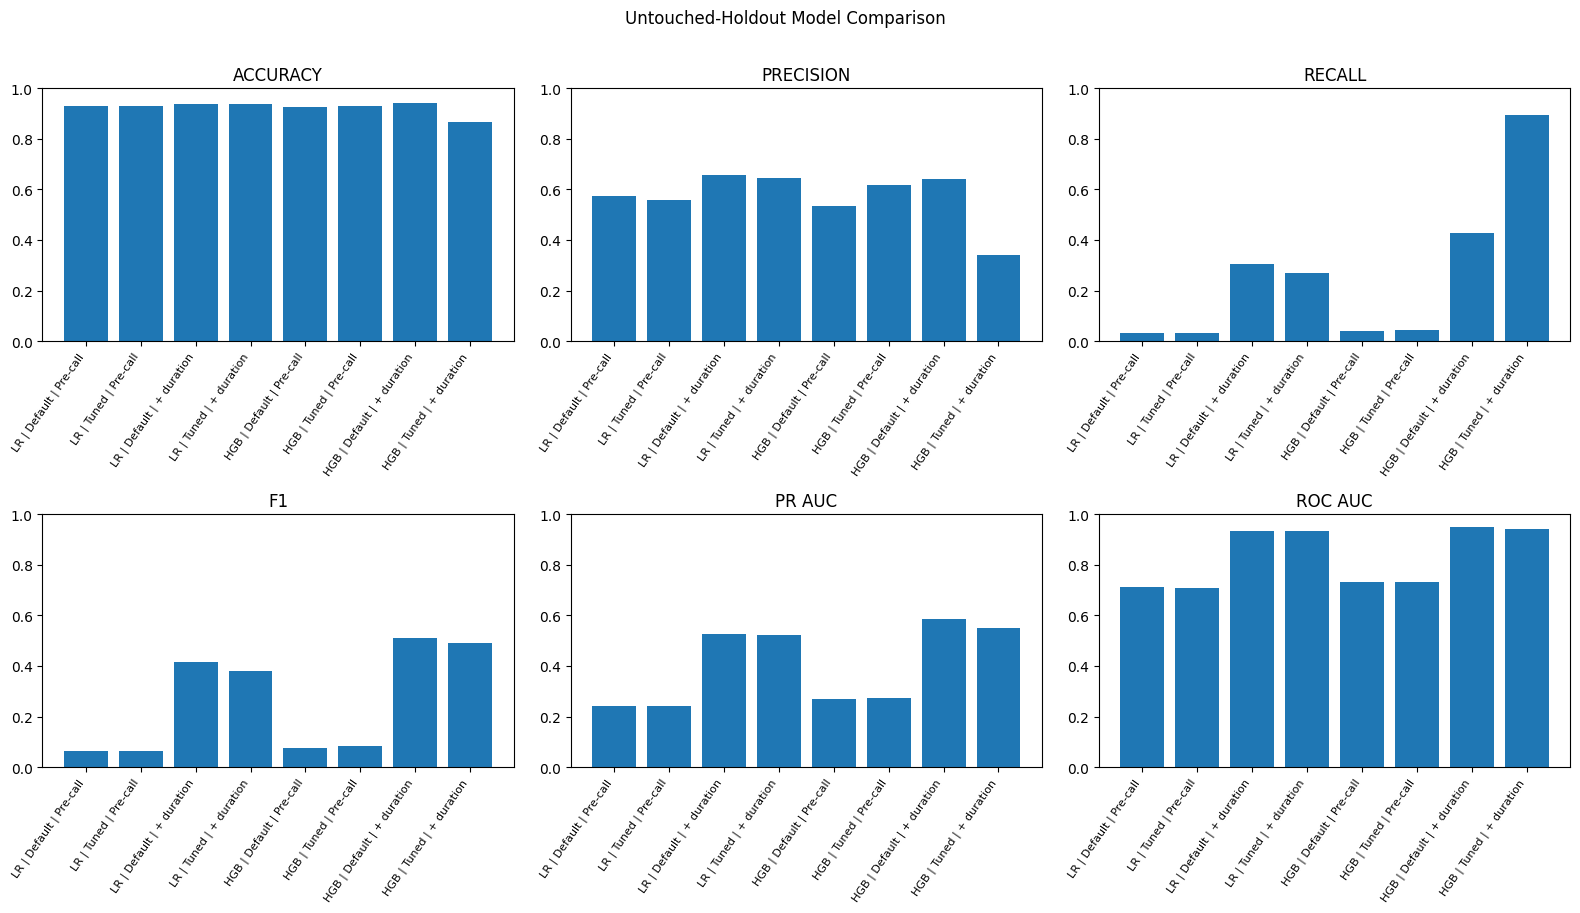

In [7]:
metrics6=["accuracy","precision","recall","f1","pr_auc","roc_auc"]; plot_df=holdout.copy(); plot_df["configuration"]=plot_df.model+" | "+plot_df.stage.replace({"Untuned/default":"Default"})+" | "+plot_df.feature_set.replace({"With duration":"+ duration"})
fig,axes=plt.subplots(2,3,figsize=(16,9)); axes=axes.ravel()
for ax,m in zip(axes,metrics6): ax.bar(range(len(plot_df)),plot_df[m]); ax.set_title(m.replace("_"," ").upper()); ax.set_ylim(0,1); ax.set_xticks(range(len(plot_df))); ax.set_xticklabels(plot_df.configuration,rotation=55,ha="right",fontsize=8)
fig.suptitle("Untouched-Holdout Model Comparison",y=1.01); plt.tight_layout(); plt.show()

## 8. Notebook-02 conclusion

Notebook 02 is the canonical source for selected hyperparameters and baseline/tuned holdout metrics. Downstream notebooks transfer only the freshly selected **pre-call** settings; they do not copy old cached values or reintroduce `duration`.